## Attention

Building the attention block of the transformer. Without the positional encodings.

In [1]:
import torch
import random
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
accelerator = "xpu" if torch.xpu.is_available() else "cpu"

### Importing the names and generating a vocabulary

In [3]:
original_words = open("../../Datasets/Names.txt", "r").read().splitlines()
words = []

for word in original_words:
    if len(word) > 7:
        continue
    words.append(word)

In [4]:
letters = sorted(set("".join(words)))

ltr_to_idx = {ltr: idx + 1 for idx, ltr in enumerate(letters)}
ltr_to_idx["."] = 0
ltr_to_idx["#"] = 27

idx_to_ltr = {idx: ltr for ltr, idx in ltr_to_idx.items()}

VOCAB_SIZE = len(ltr_to_idx)
print(f"Vocabulary size: {VOCAB_SIZE} | Words: {len(words):,}")

Vocabulary size: 28 | Words: 27,232


### Building the dataset

In [5]:
block_size = 8

def build_dataset(words, accelerator):
    Xs, Ys = [], []

    for word in words:
        complete = [0] + [ltr_to_idx[ltr] for ltr in word] + [0]

        x = complete[:-1]
        y = complete[1:]

        len_pad = block_size - len(x)

        x = x + [27] * len_pad
        y = y + [27] * len_pad

        Xs.append(x)
        Ys.append(y)

    return (
        torch.tensor(Xs, dtype=torch.int, device=accelerator),
        torch.tensor(Ys, dtype=torch.long, device=accelerator),
    )

In [6]:
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

trn_inputs, trn_outputs = build_dataset(words[:n1], accelerator)
val_inputs, val_outputs = build_dataset(words[n1:n2], accelerator)
test_inputs, test_outputs = build_dataset(words[n2:], accelerator)

for split, t in [("train", trn_inputs), ("val", val_inputs), ("test", test_inputs)]:
    print(f"{split:>5}: {t.shape[0]:>7,} examples")

train:  21,785 examples
  val:   2,723 examples
 test:   2,724 examples


### Parameters

In [8]:
sampler = torch.Generator(device=accelerator).manual_seed(42)

embedding_dimension = 30

qk_dimension = 50
v_dimension = 100

embedding_matrix = torch.randn((VOCAB_SIZE, embedding_dimension), generator=sampler, device=accelerator) * 0.1

weights_query = torch.randn((embedding_dimension, qk_dimension), generator=sampler, device=accelerator) * 0.1
weights_key = torch.randn((embedding_dimension, qk_dimension), generator=sampler, device=accelerator) * 0.1
weights_value = torch.randn((embedding_dimension, v_dimension), generator=sampler, device=accelerator) * 0.1

weights_output = torch.randn((v_dimension, VOCAB_SIZE), generator=sampler, device=accelerator) * 0.1

parameters = [embedding_matrix, weights_query, weights_key, weights_value, weights_output]

for parameter in parameters:
    parameter.requires_grad = True

print(f"Parameters: {sum(parameter.nelement() for parameter in parameters):,}")

Parameters: 9,640


## Training loop

In [9]:
def embed_inputs(inputs):
    return embedding_matrix[inputs]

In [10]:
mask = torch.triu(torch.ones(block_size, block_size, device=accelerator), diagonal=1).bool()

total_steps = 100000
lr_start    = 0.5
lr_end      = 0.01

lr_per_itrn   = []
loss_per_itrn = []
val_losses    = []
val_steps     = []

torch.xpu.synchronize()
t0 = time.time()

for step in range(1, total_steps+1):
    idx = torch.randint(0, trn_inputs.shape[0], (4096,), device=accelerator)

    embedded_inputs = embed_inputs(trn_inputs[idx])

    Query = embedded_inputs @ weights_query
    Key = embedded_inputs @ weights_key
    Value = embedded_inputs @ weights_value

    pre_softmax = (Query @ torch.transpose(Key, -1, -2)) / qk_dimension**0.5

    pre_softmax_masked = pre_softmax.masked_fill(mask, float('-inf'))

    A = torch.nn.functional.softmax(pre_softmax_masked, dim=-1)
    out = A @ Value
    logits = out @ weights_output

    loss = torch.nn.functional.cross_entropy(logits.permute(0, 2, 1), trn_outputs[idx], ignore_index=27)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lr_end + 0.5 * (lr_start - lr_end) * (1 + np.cos( np.pi * step / total_steps))
    for p in parameters:
        p.data += -lr * p.grad

    lr_per_itrn.append(lr)
    loss_per_itrn.append(loss.item())

    if step % 10000 == 0:
        with torch.no_grad():
            val_embedded_inputs = embed_inputs(val_inputs)

            val_Query = val_embedded_inputs @ weights_query
            val_Key = val_embedded_inputs @ weights_key
            val_Value = val_embedded_inputs @ weights_value

            val_pre_softmax = (val_Query @ torch.transpose(val_Key, -1, -2)) / qk_dimension**0.5
            val_pre_softmax_masked = val_pre_softmax.masked_fill(mask, float('-inf'))

            val_A = torch.nn.functional.softmax(val_pre_softmax_masked, dim=-1)
            val_out = val_A @ val_Value
            val_logits = val_out @ weights_output

            val_loss = torch.nn.functional.cross_entropy(val_logits.permute(0, 2, 1), val_outputs, ignore_index=27)

        val_losses.append(val_loss.item())
        val_steps.append(step)
        print(f"  step {step:>7,} | val {val_loss.item():.4f} | lr {lr:.4f}")

torch.xpu.synchronize()
elapsed = time.time() - t0

print(f"xpu: {elapsed}")

  step  10,000 | val 2.2993 | lr 0.4880
  step  20,000 | val 2.2926 | lr 0.4532
  step  30,000 | val 2.2944 | lr 0.3990
  step  40,000 | val 2.2872 | lr 0.3307
  step  50,000 | val 2.2865 | lr 0.2550
  step  60,000 | val 2.2857 | lr 0.1793
  step  70,000 | val 2.2853 | lr 0.1110
  step  80,000 | val 2.2852 | lr 0.0568
  step  90,000 | val 2.2851 | lr 0.0220
  step 100,000 | val 2.2851 | lr 0.0100
xpu: 1920.0456221103668


## Visualisation

In [11]:
import sys
sys.path.insert(0, '../..')
import barkeep_style as bks
bks.apply_style()

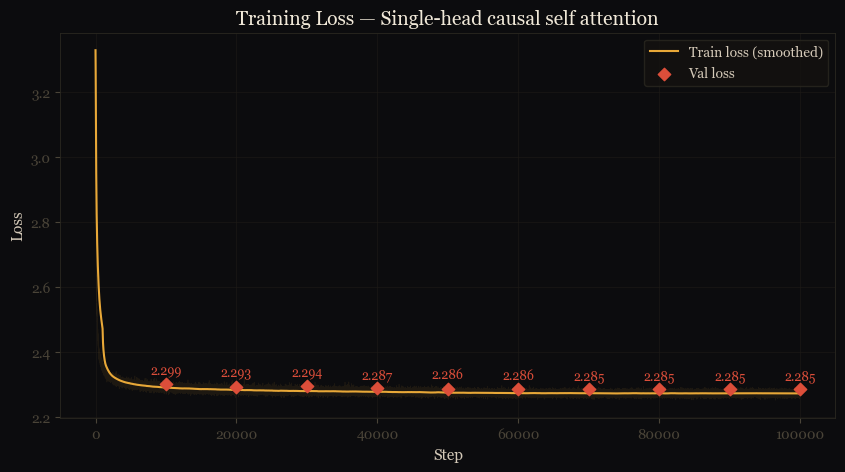

In [12]:
# Training loss curve
fig, ax = plt.subplots(figsize=(10, 5))

steps = range(len(loss_per_itrn))
ax.plot(steps, loss_per_itrn, color=bks.COLORS["amber"], alpha=0.08, linewidth=0.5)

# Windowed moving average — O(n) via prefix sums
window = 1000
arr = np.asarray(loss_per_itrn)
csum = np.concatenate(([0.0], np.cumsum(arr)))
idx = np.arange(len(arr))
lo = np.maximum(0, idx - window)
smoothed = (csum[idx + 1] - csum[lo]) / (idx + 1 - lo)
ax.plot(steps, smoothed, color=bks.COLORS["amber"], linewidth=1.5, label="Train loss (smoothed)")

ax.scatter(val_steps, val_losses, color=bks.COLORS["red"], s=40, zorder=5,
           marker="D", label="Val loss")
for s, v in zip(val_steps, val_losses):
    ax.text(s, v + 0.03, f"{v:.3f}", ha="center", fontsize=9, color=bks.COLORS["red"])

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training Loss — Single-head causal self attention")
ax.legend()
plt.show()

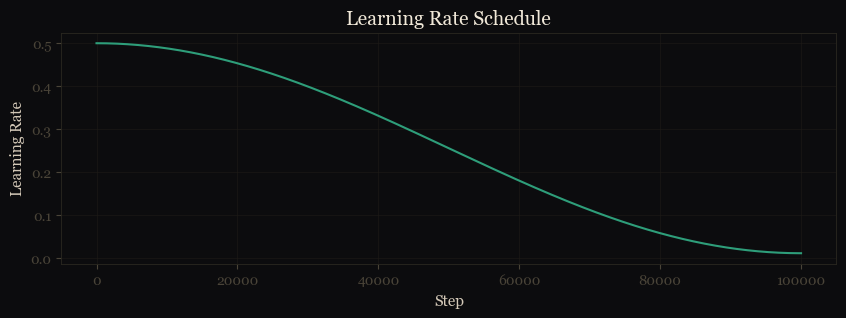

In [13]:
# Learning rate schedule
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(lr_per_itrn)), lr_per_itrn, color=bks.COLORS["teal"], linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
plt.show()

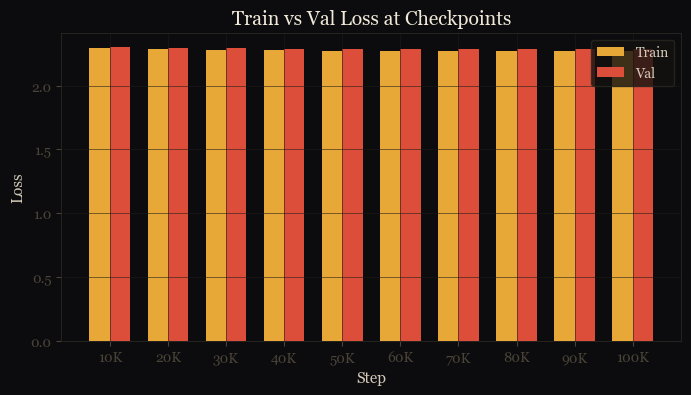

In [14]:
# Train vs val loss at checkpoints
trn_at_checkpoints = []
for s in val_steps:
    w = max(0, s - 5000)
    trn_at_checkpoints.append(sum(loss_per_itrn[w:s]) / (s - w))

fig, ax = plt.subplots(figsize=(8, 4))
x_pos, bar_w = range(len(val_steps)), 0.35
ax.bar([p - bar_w / 2 for p in x_pos], trn_at_checkpoints, bar_w, color=bks.COLORS["amber"], label="Train")
ax.bar([p + bar_w / 2 for p in x_pos], val_losses, bar_w, color=bks.COLORS["red"], label="Val")
ax.set_xticks(list(x_pos))
ax.set_xticklabels([f"{s // 1000}K" for s in val_steps])
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Train vs Val Loss at Checkpoints")
ax.legend()
plt.show()

## Evaluation

In [15]:
with torch.no_grad():
    embedded_inputs = embed_inputs(trn_inputs)

    Query = embedded_inputs @ weights_query
    Key = embedded_inputs @ weights_key
    Value = embedded_inputs @ weights_value

    pre_softmax = (Query @ torch.transpose(Key, -1, -2)) / qk_dimension**0.5

    pre_softmax_masked = pre_softmax.masked_fill(mask, float('-inf'))

    A = torch.nn.functional.softmax(pre_softmax_masked, dim=-1)
    out = A @ Value
    logits = out @ weights_output

    trn_loss = torch.nn.functional.cross_entropy(logits.permute(0, 2, 1), trn_outputs, ignore_index=27)

    # ---
    test_embedded_inputs = embed_inputs(test_inputs)

    test_Query = test_embedded_inputs @ weights_query
    test_Key = test_embedded_inputs @ weights_key
    test_Value = test_embedded_inputs @ weights_value

    test_pre_softmax = (test_Query @ torch.transpose(test_Key, -1, -2)) / qk_dimension**0.5

    test_pre_softmax_masked = test_pre_softmax.masked_fill(mask, float('-inf'))

    test_A = torch.nn.functional.softmax(test_pre_softmax_masked, dim=-1)
    test_out = test_A @ test_Value
    test_logits = test_out @ weights_output

    test_loss = torch.nn.functional.cross_entropy(test_logits.permute(0, 2, 1), test_outputs, ignore_index=27)

    print(f"Train: {trn_loss.item():.4f} | Val: {val_losses[-1]:.4f} | Test: {test_loss.item():.4f}")

Train: 2.2716 | Val: 2.2851 | Test: 2.2812


## Sampling

In [16]:
@torch.no_grad()
def sample(max_new=20):
    context = [0] + [27] * (block_size - 1)
    out = []

    for _ in range(max_new):
        x = torch.tensor([context], device=accelerator)
        emb = embed_inputs(x)

        Q = emb @ weights_query
        K = emb @ weights_key
        V = emb @ weights_value

        scores = (Q @ K.transpose(-1, -2)) / qk_dimension**0.5
        scores = scores.masked_fill(mask, float('-inf'))
        A = torch.softmax(scores, dim=-1)
        logits = (A @ V) @ weights_output

        pos = len([c for c in context if c != 27]) - 1
        next_logits = logits[0, pos]

        probs = torch.softmax(next_logits, dim=-1)
        nxt = torch.multinomial(probs, 1).item()

        if nxt == 0:
            break
        if nxt == 27:
            break

        out.append(nxt)

        if pos + 1 < block_size:
            context[pos + 1] = nxt
        else:
            context = context[1:] + [nxt]

    return ''.join(idx_to_ltr[i] for i in out)

for _ in range(20):
    print(sample())

leylal
sahann
zoynan
zaiyse
leuri
achelo
jumeir
andy
airza
ehron
pahoper
antit
jury
gradig
ulilec
brinay
asayne
rhona
proby
matorua


---